In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [2]:
train_transformer = transforms.Compose([transforms.Resize(32),
                                        transforms.CenterCrop(28),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_transfromer = transforms.Compose([transforms.Resize(32),
                                        transforms.CenterCrop(28),
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


train_data = datasets.CIFAR10("~/.pytorch/CIFAR10/", train=True, download=True, transform=train_transformer)
test_data = datasets.CIFAR10("~/.pytorch/CIFAR10/", train=False, download=True, transform=test_transfromer)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=62, shuffle=True)
testloader = torch.utils.data.DataLoader(test_data, batch_size=62, shuffle=True)

Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.70980394..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8039216].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79607844..0.92156863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9529412].


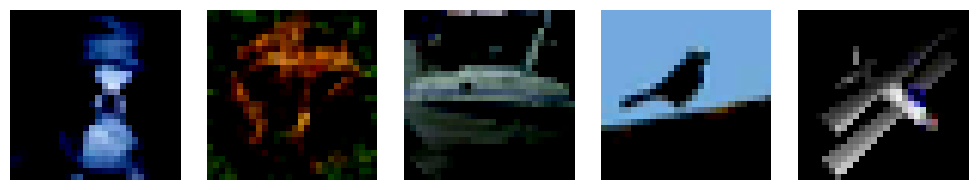

In [3]:
image, label = next(iter(trainloader))
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for n, ax in enumerate(axes):
    flat = image[n].view(-1)
    img = flat.view(3, 28, 28).permute(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()

        self.cl1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.cl2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.cl3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.maxpool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        
        self.fc1 = nn.Linear(576, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256,10)

    def forward(self, x):

        x = self.maxpool(self.bn1(F.relu(self.cl1(x))))
        x = self.maxpool(self.bn2(F.relu(self.cl2(x))))
        x = self.maxpool(self.bn3(F.relu(self.cl3(x))))
        
        x = x.view(x.shape[0], -1)

        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

model = Network()
model

Network(
  (cl1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (cl2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (cl3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=576, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [12]:
epoch = 15

total_train_loss, total_test_loss = [], []

for n in range(epoch):
    train_loss = 0
    for image, label in trainloader:
        out = model(image)
        loss_a = criterion(out, label)
        
        optimizer.zero_grad()
        loss_a.backward()
        optimizer.step()

        train_loss += loss_a.item()
    else:
        test_loss = 0
        model.eval()
        with torch.no_grad():
            for images, labels in testloader:
                out = model(images)
                loss_b = criterion(out, labels)
                test_loss += loss_b.item()        

            train_loss = train_loss/len(trainloader)
            test_loss = test_loss/len(testloader)

            total_train_loss.append(train_loss)
            total_test_loss.append(test_loss)

            print(f"Epoch: {n+1} Train loss: {train_loss:6f} Test loss: {test_loss:6f}")
        model.train()

Epoch: 1 Train loss: 1.748271 Test loss: 1.617562
Epoch: 2 Train loss: 1.659489 Test loss: 1.537566
Epoch: 3 Train loss: 1.595463 Test loss: 1.482710
Epoch: 4 Train loss: 1.549393 Test loss: 1.438102
Epoch: 5 Train loss: 1.505444 Test loss: 1.393528
Epoch: 6 Train loss: 1.465532 Test loss: 1.363521
Epoch: 7 Train loss: 1.438739 Test loss: 1.331581
Epoch: 8 Train loss: 1.405281 Test loss: 1.295736
Epoch: 9 Train loss: 1.377527 Test loss: 1.292374
Epoch: 10 Train loss: 1.350959 Test loss: 1.243834
Epoch: 11 Train loss: 1.326107 Test loss: 1.226519
Epoch: 12 Train loss: 1.309778 Test loss: 1.199417
Epoch: 13 Train loss: 1.285106 Test loss: 1.197436
Epoch: 14 Train loss: 1.264988 Test loss: 1.160232
Epoch: 15 Train loss: 1.241318 Test loss: 1.147132


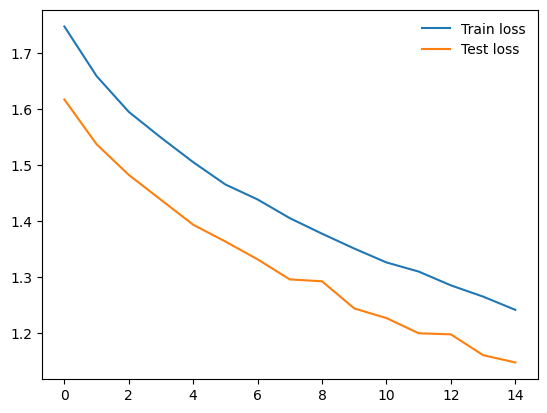

In [13]:
plt.plot(total_train_loss, label='Train loss')
plt.plot(total_test_loss, label = 'Test loss')
plt.legend(frameon =False)
plt.show()

In [14]:
torch.save(model.state_dict(), 'Point15.pth')